In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import nibabel as nib
import numpy as np
# ===== LOAD FUNCTION =====
def load_ev(path):
    try:
        return pd.read_csv(
            path,
            sep=r"\s+",
            header=None,
            names=["onset", "duration", "amplitude"]
        )
    except Exception as e:
        print(f"Skipping {path}: {e}")
        return None

# ===== PLOT FUNCTION =====
def plot_scan(scan_dir, data_dir, ax):
    ev_files = sorted(scan_dir.glob("*.txt"))

    if len(ev_files) == 0:
        return

    # plt.figure(figsize=(10, 3))
    

    y_labels = []
    y_pos = []
    c = 0

    for i, ev_file in enumerate(ev_files):
        if "Sync" in ev_file.name:
            continue
        if "present" in ev_file.name:
            continue
        df = load_ev(ev_file)
        if df is None or df.empty:
            continue
        # print(df)
        if df['duration'].min() < 5:
            continue

        y = c 
        y_labels.append(ev_file.name)
        y_pos.append(y)

        # plot each event as a horizontal bar
        for _, row in df.iterrows():
            ax.barh(
                y,
                row["duration"],
                left=row["onset"],
                color='black',
            )
        c += 1
    # ax.set_yticks(y_pos)
    # ax.set_yticklabels(y_labels)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels)
    print(f"Plotted {len(y_labels)} events for {scan_dir.name}")
    
    # load the image file using nibabel
    # img_file = glob(str(data_dir)+"/tfMRI_"+str(scan_dir.name)+"*.dtseries.nii", recursive=True)
    img_file = [str(data_dir)+f"/tfMRI_{scan_dir.name}_RL_Atlas_MSMAll.dtseries.nii"]
    if len(img_file) == 0:
        print(f"No image file found for {scan_dir.name}")
        return
    img = nib.load(img_file[0])
    # get the number of time points (volumes) in the image    
    n_volumes = img.shape[0]
    # calculate the total duration of the scan inseconds
    total_duration = n_volumes * 0.72
    ax.set_xlim(0, total_duration)

    # plt.yticks(y_pos, y_labels)
    # plt.xlabel("Time (s)")
    # plt.xlim(0, total_duration)
    # plt.title(f"{scan_dir.name} – All Events")
    # plt.tight_layout()
    return ax

    # out_path = OUTPUT_DIR / f"{scan_dir.name}.png"
    # plt.savefig(out_path, dpi=150)
    # plt.close()

    # print(f"Saved: {out_path}")


Plotted 2 events for EMOTION


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Plotted 2 events for GAMBLING
Plotted 2 events for LANGUAGE


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Plotted 5 events for MOTOR


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Plotted 2 events for RELATIONAL


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Plotted 3 events for SOCIAL
Plotted 8 events for WM


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


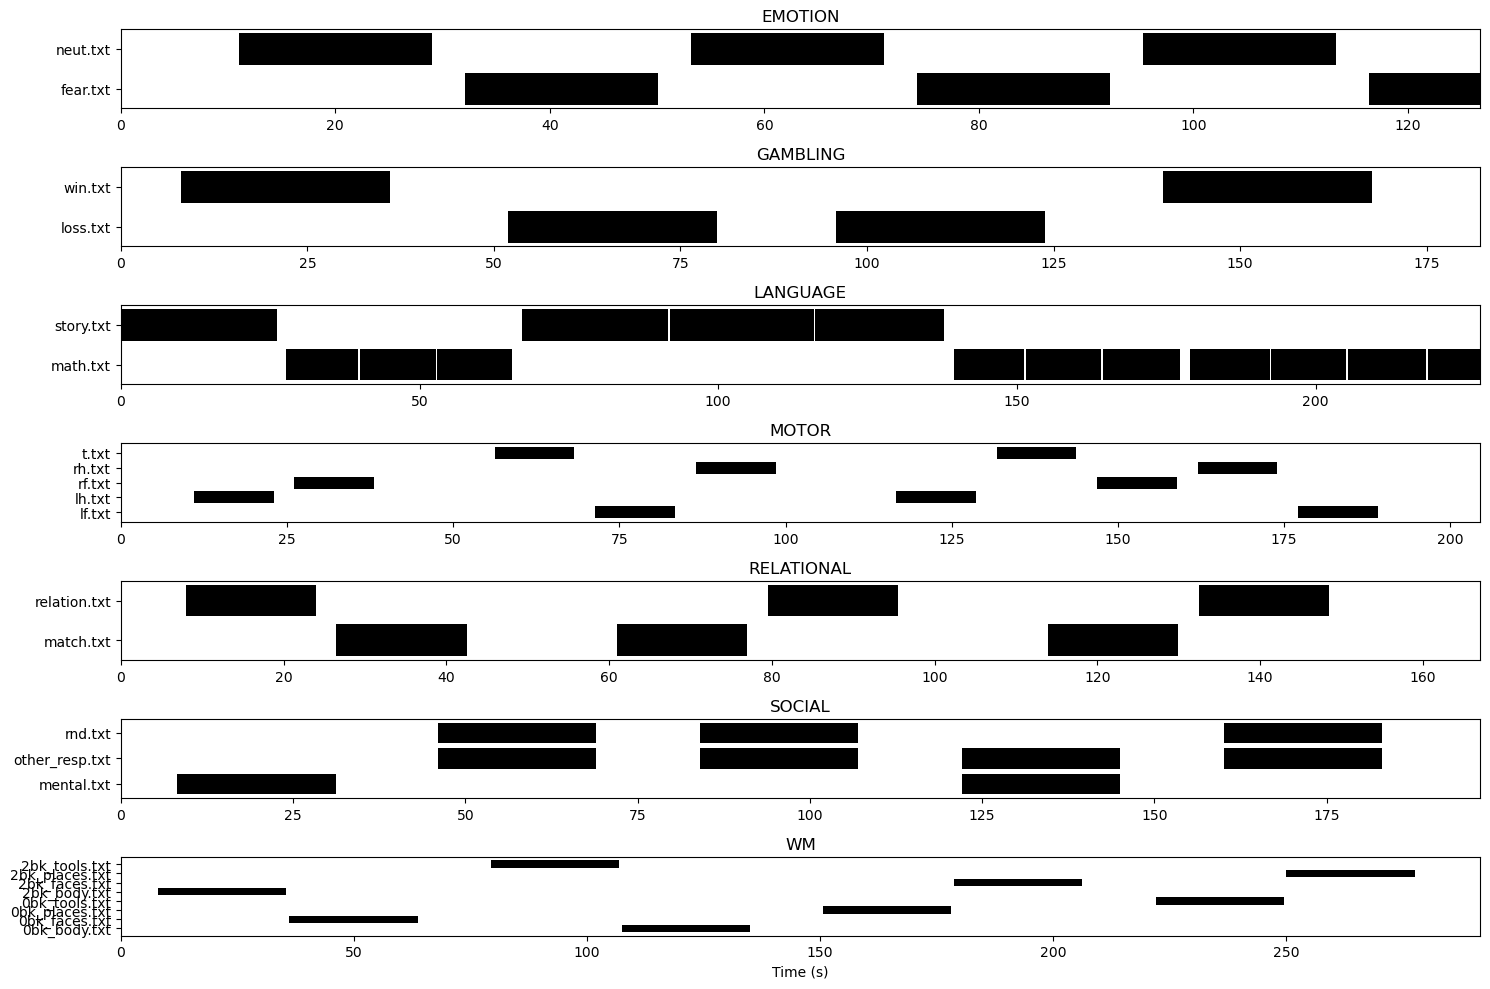

In [47]:
# ===== CONFIG =====
BASE_DIR = Path("paper/data/raw/101006/EVs")  # change if needed
data_dir = Path("paper/data/raw/101006/fMRI")
OUTPUT_DIR = Path("ev_plots")
OUTPUT_DIR.mkdir(exist_ok=True)
scan_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir()]

fig,axs = plt.subplots(7,1, figsize=(15, 10))
for i,scan in enumerate(sorted(scan_dirs)):
    # print(f"Processing {scan.name}")
    plot_scan(scan, data_dir, axs[i])
    axs[i].set_title(scan.name)
axs[i].set_xlabel("Time (s)")
plt.tight_layout()